To jest mój stary kod do ARIMY zostawiam go tutaj sobie - potem bede go i tak ogarniał bardziej // Janek

In [90]:
import yfinance as yf

ticker = 'SPY'
data = yf.download(
    ticker,
    start='2025-01-01',
    end='2026-04-20',
    interval='1d',
    progress=False)

data.dropna()
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,323.000000,323.000000,323.000000,323.000000,3.230000e+02
mean,628.734604,631.931502,624.812711,628.499467,7.532223e+07
std,50.232177,49.454670,51.117946,50.375683,2.840875e+07
min,490.853088,515.787225,476.339470,483.645729,2.604870e+07
25%,589.105682,591.149053,585.639723,588.744538,6.006955e+07
50%,638.325623,640.369995,636.778707,638.623025,7.053890e+07
75%,675.754517,678.147981,671.483076,674.903364,8.670800e+07
max,710.140015,712.390015,705.760010,706.140015,2.566114e+08


In [91]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(data['Close'])

print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -0.659253
p-value: 0.857024


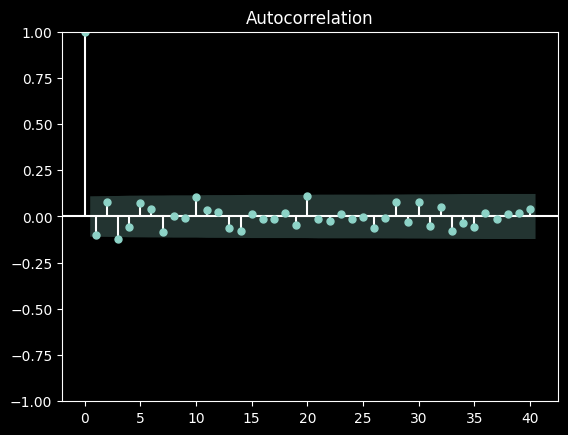

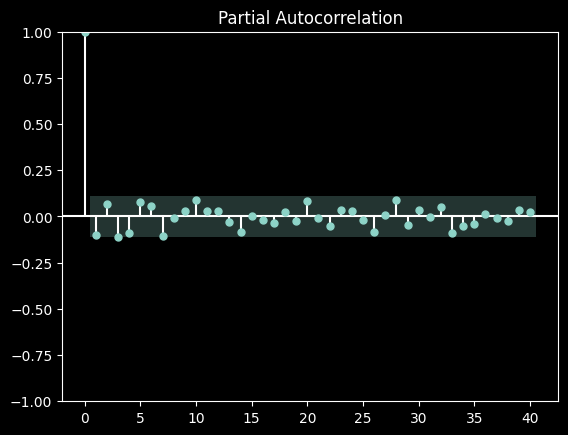

In [92]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

data['Diff Close'] = data['Close'].diff(1)
data.dropna(inplace = True)

plot_acf(data['Diff Close'], lags=40)
plot_pacf(data['Diff Close'], lags=40)
plt.show()

In [93]:
train_size = int(len(data) * 0.8)
train, test = data.iloc[:train_size], data.iloc[train_size:]

In [96]:
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train["Close"], order=(2,1,1), seasonal_order=(1 , 1 , 1, 25))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))
test_close = test['Close'][:len(forecast)]
rmse = np.sqrt(mean_squared_error(test['Close'], forecast))

print(f"{model_fit.summary()} \n")
print(f"Przewidywana cena: {forecast} \n")
print(f"AIC: {model_fit.aic} \n")
print(f"BIC: {model_fit.bic} \n")
print(f"RMSE: {rmse:.4f}")

C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting 

                                     SARIMAX Results                                      
Dep. Variable:                                SPY   No. Observations:                  257
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 25)   Log Likelihood                -789.309
Date:                            Mon, 20 Apr 2026   AIC                           1590.618
Time:                                    20:20:34   BIC                           1611.272
Sample:                                         0   HQIC                          1598.948
                                            - 257                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5153      0.444     -1.161      0.246      -1.385       0.355
ar.L2          0.0650      0.107   

C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\janek\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


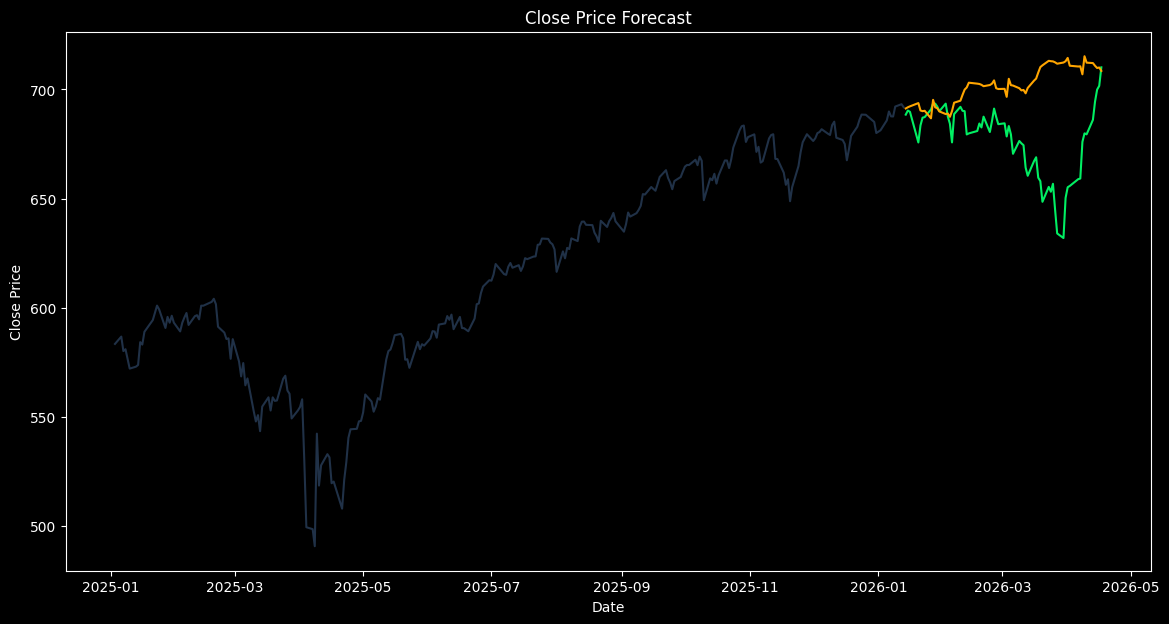

In [97]:
plt.figure(figsize=(14,7))
plt.plot(train.index, train["Close"], label='Train', color='#203147')
plt.plot(test.index, test["Close"], label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

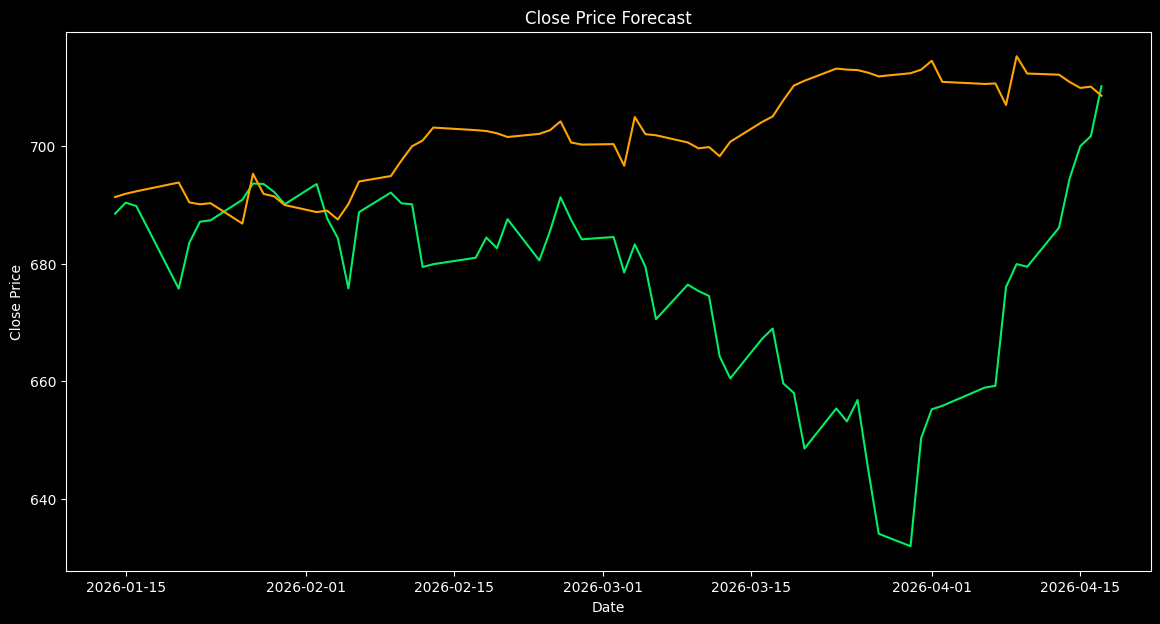

In [98]:
plt.figure(figsize=(14,7))
plt.plot(test.index, test["Close"], label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()